<a href="https://colab.research.google.com/github/Sparkydev007/COLAB-Notebooks/blob/main/NLP_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

from tensorflow.keras import layers, models

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 images into 1D vector
    layers.Dense(512, activation='relu'),  # Fully connected hidden layer with ReLU
    layers.Dropout(0.2),                   # Dropout layer to reduce overfitting
    layers.Dense(10, activation='softmax') # Output layer with 10 classes (digits 0-9)
])


Num GPUs Available:  0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MNIST Classification: This code builds a simple feedforward neural network using TensorFlow & Keras to classify handwritten digits (0–9) from the MNIST dataset. It flattens 28×28 images, uses a 512-neuron hidden layer with ReLU, applies 20% dropout to reduce overfitting, and outputs class probabilities with a softmax layer. Pixel values are normalized to [0, 1], and the model can run on CPU or GPU.






In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

MNIST Classifier Model: This code defines a feedforward neural network using TensorFlow & Keras.

Input: 28×28 images

Flatten Layer: Converts images to 1D vectors

Dense Layer: 512 neurons with ReLU activation

Dropout: 10% to prevent overfitting

Output Layer: 10 neurons with Softmax activation for digit classification (0–9)

model.summary() displays the network architecture and parameter counts.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8894 - loss: 0.3822 - val_accuracy: 0.9642 - val_loss: 0.1187
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9677 - loss: 0.1031 - val_accuracy: 0.9629 - val_loss: 0.1179
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9815 - loss: 0.0611 - val_accuracy: 0.9754 - val_loss: 0.0833
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9845 - loss: 0.0470 - val_accuracy: 0.9773 - val_loss: 0.0759
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.9754 - val_loss: 0.0839
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9916 - loss: 0.0260 - val_accuracy: 0.9772 - val_loss: 0.0762
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0210 - val_accuracy: 0.9771 - val_loss: 0.0868
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9942 - loss: 0.0187 

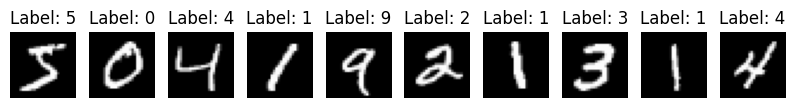

In [ ]:
import matplotlib.pyplot as plt

deep_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

Deep MNIST Classifier & Sample Visualization:

A deep feedforward network with 3 hidden layers (512 → 256 → 128 neurons) and Dropout (20%) to reduce overfitting.

Output layer: 10 neurons with Softmax for digit classification (0–9).

Training: Adam optimizer, sparse categorical crossentropy, batch size 32, 10 epochs, 20% validation split.

The plot displays the first 10 training images with their corresponding labels for a quick data overview.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


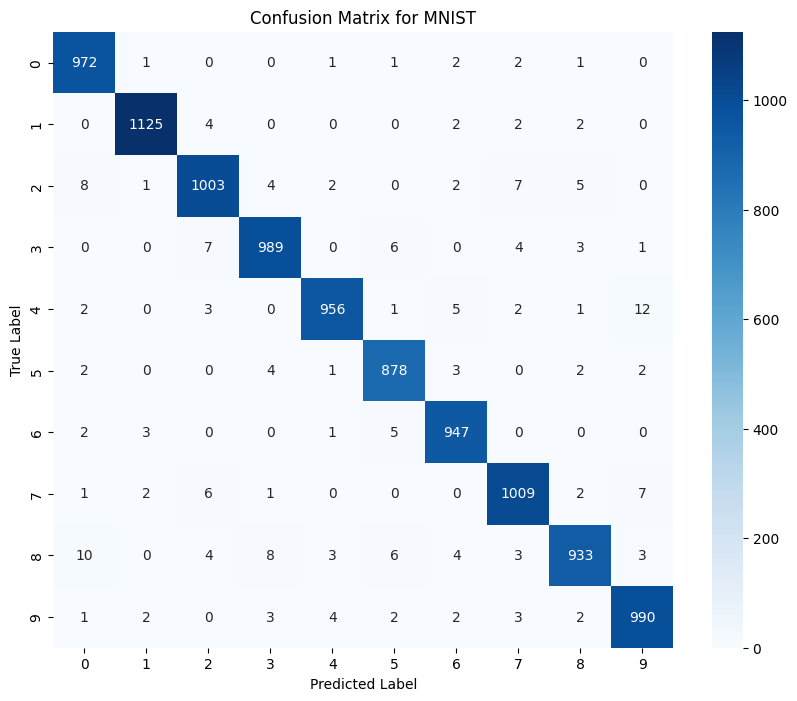

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST')
plt.show()

Confusion Matrix for MNIST Predictions:

y_pred contains model predictions on the test set, converted to class labels using argmax.

confusion_matrix from sklearn compares true vs predicted labels.

The heatmap shows correct and misclassified digits, helping identify which digits the model confuses most.

Axes: X → Predicted Label, Y → True Label.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9866 - loss: 0.0446 - val_accuracy: 0.9778 - val_loss: 0.0930
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9890 - loss: 0.0345 - val_accuracy: 0.9793 - val_loss: 0.0874
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9910 - loss: 0.0317 - val_accuracy: 0.9793 - val_loss: 0.0973
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9901 - loss: 0.0336 - val_accuracy: 0.9797 - val_loss: 0.0877
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9914 - loss: 0.0281 - val_accuracy: 0.9804 - val_loss: 0.1010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9913 - loss: 0.0276 - val_accuracy: 0.9793 - val_loss: 0.0989
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9787 - val_loss: 0.1023
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0292 -

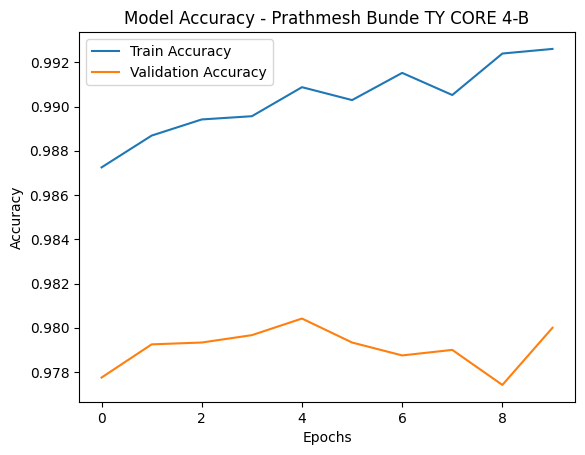

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = deep_model.fit(x_train, y_train, epochs=10, validation_split=0.2)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy - Prathmesh Bunde TY CORE 4-B')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

y_pred = deep_model.predict(x_test).argmax(axis=1)
print(classification_report(y_test, y_pred))


Deep MNIST Classifier Training & Evaluation:

Trains the deep feedforward network (deep_model) with 3 hidden layers on MNIST for 10 epochs using Adam optimizer and sparse categorical crossentropy loss.

Plots training vs validation accuracy with the title: "Model Accuracy - Prathmesh Bunde TY CORE 4-B".

Generates a classification report showing precision, recall, and F1-score for each digit (0–9), giving detailed performance metrics on the test set.